In [ ]:
#pip install xgboost

In [ ]:
#pip install tensorflow

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
#os.getcwd()

In [ ]:
#os.chdir('c:\\Users\\saran.t\\Downloads')

#### 1. **Upload DF and Simulation**

In [ ]:
#https://drive.google.com/file/d/1BztqvNY5unlVSYGTRtloKzZzBe8qH8UY/view?usp=sharing
#df = pd.read_csv('train.csv')
#df

# Use the correct file ID
file_id = "1BztqvNY5unlVSYGTRtloKzZzBe8qH8UY"
url = f"https://drive.google.com/uc?id={file_id}"

# Read CSV file
df = pd.read_csv(url)

# Display first 5 rows
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [ ]:
# Define the columns to check
columns_to_check = [
    'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
    'Customer_rating', 'Prior_purchases', 'Product_importance', 'Gender',
    'Discount_offered', 'Reached.on.Time_Y.N'
]

# Get unique values for each column
unique_values = {col: df[col].unique() for col in columns_to_check}

# Display unique values
for col, values in unique_values.items():
    print(f"Unique values in '{col}': {values}\n")

Unique values in 'Warehouse_block': ['D' 'F' 'A' 'B' 'C']

Unique values in 'Mode_of_Shipment': ['Flight' 'Ship' 'Road']

Unique values in 'Customer_care_calls': [4 2 3 5 6 7]

Unique values in 'Customer_rating': [2 5 3 1 4]

Unique values in 'Prior_purchases': [ 3  2  4  6  5  7 10  8]

Unique values in 'Product_importance': ['low' 'medium' 'high']

Unique values in 'Gender': ['F' 'M']

Unique values in 'Discount_offered': [44 59 48 10 46 12  3 11 29 32  1 43 45  6 36 18 38 51  2 28 24 31 61 22
  4 62 16 56 15  9 40 37 41 17 64 52 49 39 14 33 21 13 23 26 57  7 35  8
  5 53 55 47 65 25 50 60 20 19 63 58 34 54 27 42 30]

Unique values in 'Reached.on.Time_Y.N': [1 0]



In [ ]:
pd.set_option('display.max_columns', None)

# Define promotion types
promo_condition = [(df['Discount_offered']<=5), (df['Discount_offered']<=15),(df['Discount_offered']<=45),(df['Discount_offered']>45)]
promo_choice = ['Thank_you_Customer_Coupon', 'Flash_Sales_Coupon', '10thAnni_Promo', 'Clearance_Promo']
df['promo_type'] = np.select(promo_condition,promo_choice)

# Define mappings for multipliers
warehouse_multiplier_map = {'A': 0.05, 'B': 0.07, 'C': 0.09, 'D': 0.03, 'F': 0.11}
shipment_multiplier_map = {'Flight': 0.15, 'Ship': 0.03, 'Road': 0.05}
importance_multiplier_map = {'low': 0.025, 'medium': 0.05, 'high': 0.1}

# Apply multipliers
df['warehouse_multiplier'] = df['Warehouse_block'].map(warehouse_multiplier_map)
df['shipment_multiplier'] = df['Mode_of_Shipment'].map(shipment_multiplier_map)
df['importance_multiplier'] = df['Product_importance'].map(importance_multiplier_map)

# calculate total cost multiplier include 35% of pofit target before discount
df['total_multiplier'] = df['warehouse_multiplier']+(df['shipment_multiplier']*df['Weight_in_gms']/1000)+df['importance_multiplier'] + 0.35 + 1

df['price'] = (df['Cost_of_the_Product']*df['total_multiplier'])

df['quantity'] = np.random.randint(1,100, df.shape[0])
df['total_cost'] = df['quantity']*df['Cost_of_the_Product']
df['sales_amount_before_discount'] = df['quantity']*df['price']
df['sales_amount_after_discount_excluding_vat'] = df['quantity']*(1-df['Discount_offered']/100)*df['price']
df['sales_amount_after_discount_including_vat'] = (df['quantity']*(1-df['Discount_offered']/100)*df['price'])*1.07
df['discount_amount'] = df['sales_amount_before_discount'] - df['sales_amount_after_discount_excluding_vat']
df['gross_profit'] = df['sales_amount_after_discount_excluding_vat'] - (df['Cost_of_the_Product']*df['quantity'])


# Create mappings for encoding categorical variables (starting from 1)
text_columns = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender','promo_type']
text_mappings = {col: {val: i+1 for i, val in enumerate(sorted(df[col].unique()))} for col in text_columns}

# Apply encoding
for col in text_columns:
    df[f'{col}_encoded'] = df[col].map(text_mappings[col])

df

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,promo_type,warehouse_multiplier,shipment_multiplier,importance_multiplier,total_multiplier,price,quantity,total_cost,sales_amount_before_discount,sales_amount_after_discount_excluding_vat,sales_amount_after_discount_including_vat,discount_amount,gross_profit,Warehouse_block_encoded,Mode_of_Shipment_encoded,Product_importance_encoded,Gender_encoded,promo_type_encoded
0,1,D,Flight,4,2,177,3,low,F,44,1233,1,10thAnni_Promo,0.03,0.15,0.025,1.58995,281.42115,79,13983,22232.27085,12450.071676,13321.576693,9782.199174,-1532.928324,4,1,2,1,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1,Clearance_Promo,0.11,0.15,0.025,1.94820,420.81120,68,14688,28615.16160,11732.216256,12553.471394,16882.945344,-2955.783744,5,1,2,2,2
2,3,A,Flight,2,2,183,4,low,M,48,3374,1,Clearance_Promo,0.05,0.15,0.025,1.93110,353.39130,4,732,1413.56520,735.053904,786.507677,678.511296,3.053904,1,1,2,2,2
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1,Flash_Sales_Coupon,0.07,0.15,0.050,1.64655,289.79280,2,352,579.58560,521.627040,558.140933,57.958560,169.627040,2,1,3,2,3
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1,Clearance_Promo,0.09,0.15,0.050,1.86260,342.71840,75,13800,25703.88000,13880.095200,14851.701864,11823.784800,80.095200,3,1,3,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1,Thank_you_Customer_Coupon,0.05,0.03,0.050,1.49614,377.02728,36,9072,13572.98208,13437.252259,14377.859917,135.729821,4365.252259,1,3,3,1,4
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0,Flash_Sales_Coupon,0.07,0.03,0.050,1.50741,349.71912,69,16008,24130.61928,22682.782123,24270.576872,1447.837157,6674.782123,2,3,3,1,3
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0,Thank_you_Customer_Coupon,0.09,0.03,0.025,1.49965,362.91530,26,6292,9435.79780,9058.365888,9692.451500,377.431912,2766.365888,3,3,2,1,4
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0,Thank_you_Customer_Coupon,0.11,0.03,0.050,1.54630,344.82490,26,5798,8965.44740,8786.138452,9401.168144,179.308948,2988.138452,5,3,3,2,4


In [ ]:
df[['Warehouse_block','total_cost','sales_amount_before_discount','sales_amount_after_discount_excluding_vat',
    'sales_amount_after_discount_including_vat','gross_profit']].groupby(['Warehouse_block']).sum().applymap(lambda x:f"{x:,.2f}")

,total_cost,sales_amount_before_discount,sales_amount_after_discount_excluding_vat,sales_amount_after_discount_including_vat,gross_profit
Warehouse_block,,,,,
A,"19,279,032.00","31,473,033.91","27,529,746.06","29,456,828.28","8,250,714.06"
B,"19,096,229.00","31,512,271.65","27,716,075.91","29,656,201.22","8,619,846.91"
C,"19,799,781.00","33,132,436.46","29,036,591.56","31,069,152.97","9,236,810.56"
D,"19,232,447.00","31,051,010.73","27,158,478.60","29,059,572.10","7,926,031.60"
F,"39,013,340.00","65,803,985.58","57,285,683.74","61,295,681.60","18,272,343.74"


In [ ]:
df[['promo_type','total_cost','sales_amount_before_discount','sales_amount_after_discount_excluding_vat',
    'sales_amount_after_discount_including_vat','gross_profit']].groupby(['promo_type']).sum().applymap(lambda x:f"{x:,.2f}")

,total_cost,sales_amount_before_discount,sales_amount_after_discount_excluding_vat,sales_amount_after_discount_including_vat,gross_profit
promo_type,,,,,
10thAnni_Promo,"13,685,953.00","22,039,406.66","15,307,018.95","16,378,510.28","1,621,065.95"
Clearance_Promo,"9,803,990.00","15,639,086.64","7,014,421.35","7,505,430.84","-2,789,568.65"
Flash_Sales_Coupon,"48,055,981.00","80,269,105.44","73,636,105.16","78,790,632.52","25,580,124.16"
Thank_you_Customer_Coupon,"44,874,905.00","75,025,139.60","72,769,030.40","77,862,862.52","27,894,125.40"


In [ ]:
df[['Warehouse_block','promo_type','total_cost','sales_amount_before_discount','sales_amount_after_discount_excluding_vat',
    'sales_amount_after_discount_including_vat','gross_profit']].groupby(['Warehouse_block','promo_type']).sum().applymap(lambda x:f"{x:,.2f}")

total_cost  \
Warehouse_block promo_type                                 
A               10thAnni_Promo              2,039,525.00   
                Clearance_Promo             1,712,970.00   
                Flash_Sales_Coupon          8,211,312.00   
                Thank_you_Customer_Coupon   7,315,225.00   
B               10thAnni_Promo              2,284,366.00   
                Clearance_Promo             1,352,485.00   
                Flash_Sales_Coupon          7,984,138.00   
                Thank_you_Customer_Coupon   7,475,240.00   
C               10thAnni_Promo              2,265,000.00   
                Clearance_Promo             1,626,950.00   
                Flash_Sales_Coupon          8,202,393.00   
                Thank_you_Customer_Coupon   7,705,438.00   
D               10thAnni_Promo              2,200,077.00   
                Clearance_Promo             1,664,250.00   
                Flash_Sales_Coupon          7,764,916.00   
                Thank_you_Customer_Coupon   7,603,204.00   
F               10thAnni_Promo              4,896,985.00   
                Clearance_Promo             3,447,335.00   
                Flash_Sales_Coupon         15,893,222.00   
                Thank_you_Customer_Coupon  14,775,798.00   

                                          sales_amount_before_discount  \
Warehouse_block promo_type                                               
A               10thAnni_Promo                            3,244,369.60   
                Clearance_Promo                           2,682,917.64   
                Flash_Sales_Coupon                       13,550,628.74   
                Thank_you_Customer_Coupon                11,995,117.93   
B               10thAnni_Promo                            3,628,601.64   
                Clearance_Promo                           2,147,389.39   
                Flash_Sales_Coupon                       13,281,563.41   
                Thank_you_Customer_Coupon                12,454,717.20   
C               10thAnni_Promo                            3,655,907.80   
                Clearance_Promo                           2,618,254.29   
                Flash_Sales_Coupon                       13,764,834.41   
                Thank_you_Customer_Coupon                13,093,439.96   
D               10thAnni_Promo                            3,484,603.05   
                Clearance_Promo                           2,595,595.15   
                Flash_Sales_Coupon                       12,588,862.72   
                Thank_you_Customer_Coupon                12,381,949.82   
F               10thAnni_Promo                            8,025,924.56   
                Clearance_Promo                           5,594,930.16   
                Flash_Sales_Coupon                       27,083,216.16   
                Thank_you_Customer_Coupon                25,099,914.70   

                                          sales_amount_after_discount_excluding_vat  \
Warehouse_block promo_type                                                            
A               10thAnni_Promo                                         2,262,583.87   
                Clearance_Promo                                        1,202,843.89   
                Flash_Sales_Coupon                                    12,428,469.19   
                Thank_you_Customer_Coupon                             11,635,849.11   
B               10thAnni_Promo                                         2,497,780.00   
                Clearance_Promo                                          965,675.23   
                Flash_Sales_Coupon                                    12,175,144.16   
                Thank_you_Customer_Coupon                             12,077,476.52   
C               10thAnni_Promo                                         2,540,980.80   
                Clearance_Promo                                        1,178,036.83   
                Flash_Sales_Coupon                  

#### 2. **Advance EDA**

In [ ]:
pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from ydata_profiling import ProfileReport


# Generate EDA report
profile = ProfileReport(df, title="EDA Report", explorative=True)

# Save as HTML file
profile.to_file("EDA_Report.html")

# Display message
print("EDA report generated: Click to download -> EDA_Report.html")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

EDA report generated: Click to download -> EDA_Report.html


#### 3.**Pridiction**

Epoch 1/20


/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 319239552.0000
Epoch 2/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 117908480.0000
Epoch 3/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 79031152.0000
Epoch 4/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 66157208.0000
Epoch 5/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 51702212.0000
Epoch 6/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 34359380.0000
Epoch 7/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 19269382.0000
Epoch 8/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 10046642.0000
Epoch 9/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6579375.5000
Epoch 10/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5591883.5000
Epoch 11/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4689301.0000
Epoch 12/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3905747.5000
Epoch 13/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3599983.5000
Epoch 14/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/

/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 312914464.0000
Epoch 2/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 114263864.0000
Epoch 3/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 79575720.0000
Epoch 4/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 65719536.0000
Epoch 5/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 52661628.0000
Epoch 6/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 37190336.0000
Epoch 7/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 22268158.0000
Epoch 8/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11360248.0000
Epoch 9/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6758508.0000
Epoch 10/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5337847.5000
Epoch 11/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4232657.5000
Epoch 12/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3562630.7500
Epoch 13/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3136191.0000
Epoch 14/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 317200992.0000
Epoch 2/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 120965312.0000
Epoch 3/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 106910280.0000
Epoch 4/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 106413136.0000
Epoch 5/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 104733184.0000
Epoch 6/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 104154856.0000
Epoch 7/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 104706952.0000
Epoch 8/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 102113456.0000
Epoch 9/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 97951064.0000
Epoch 10/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 99998416.0000
Epoch 11/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 99684472.0000
Epoch 12/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 100627864.0000
Epoch 13/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 100555744.0000
Epoch 14/20
550/550 ━━━━━━━━━━━━━━━

/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


550/550 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 311073536.0000
Epoch 2/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 99898616.0000
Epoch 3/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 47738244.0000
Epoch 4/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6188663.5000
Epoch 5/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2562955.5000
Epoch 6/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1160307.8750
Epoch 7/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 906499.5625
Epoch 8/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 671937.6250
Epoch 9/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 635275.2500
Epoch 10/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 458692.9062
Epoch 11/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 386020.5938
Epoch 12/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 393327.5312
Epoch 13/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 349634.3750
Epoch 14/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 

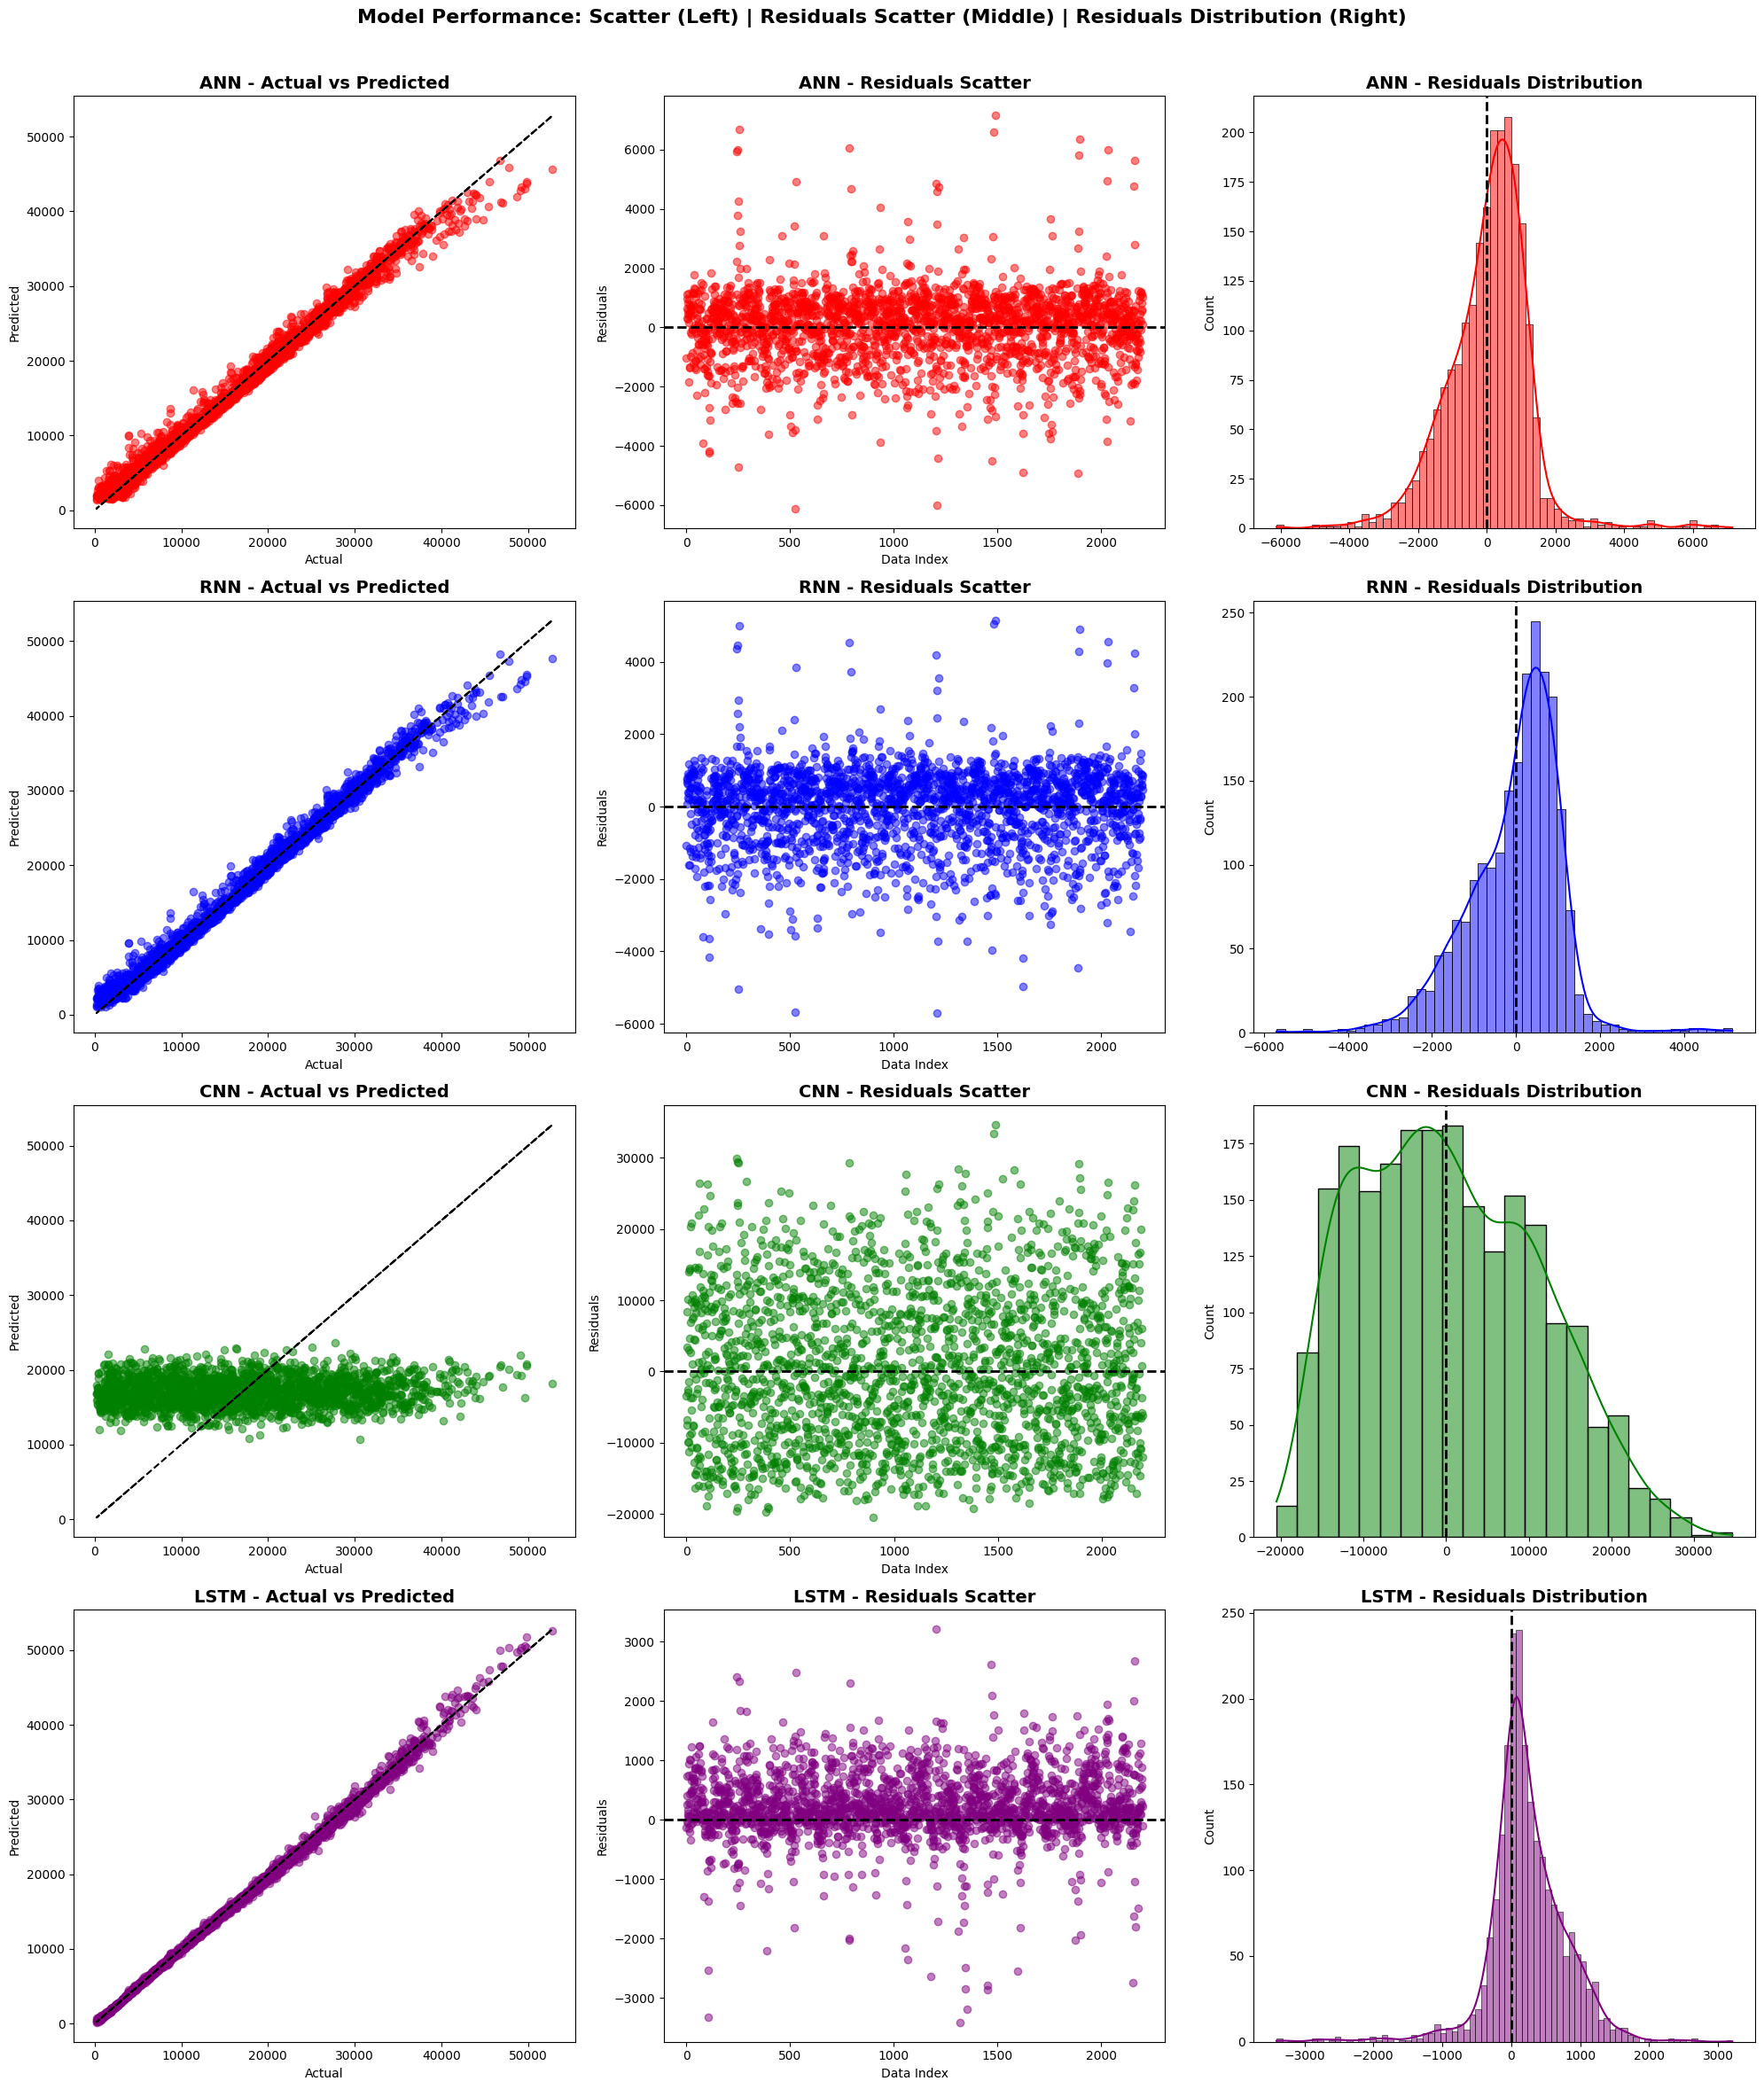

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Conv1D, Flatten
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Load and preprocess dataset
df = df

# Define features and target
features = ['Customer_care_calls', 'Customer_rating', 'Prior_purchases',
            'Discount_offered', 'Weight_in_gms', 'price', 'quantity',
            'total_cost', 'Warehouse_block_encoded',
            'Mode_of_Shipment_encoded', 'Product_importance_encoded',
            'Gender_encoded', 'promo_type_encoded']
target = 'sales_amount_after_discount_excluding_vat'

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[features])
y = df[target].values

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=False)

# Reshape data for RNN/LSTM (samples, timesteps, features)
X_train_rnn, X_test_rnn = X_train.reshape(-1, 1, X_train.shape[1]), X_test.reshape(-1, 1, X_test.shape[1])

# Store predictions for plotting later
model_predictions = {}

# Function to train & evaluate models
def train_and_evaluate(model, X_train, y_train, X_test, y_test, name):
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

    y_pred = model.predict(X_test).flatten()
    model_predictions[name] = y_pred  # Store predictions

    mse, rmse, mae = mean_squared_error(y_test, y_pred), np.sqrt(mean_squared_error(y_test, y_pred)), mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / np.maximum(y_test, 1e-8))) * 100  # Avoid division by zero

    print(f"📌 {name} - MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%")

    return mse, rmse, mae, mape

# 🚀 ANN Model
ann_model = Sequential([Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
                        Dense(32, activation='relu'),
                        Dense(1)])
ann_mse, ann_rmse, ann_mae, ann_mape = train_and_evaluate(ann_model, X_train, y_train, X_test, y_test, "ANN")

# 🚀 RNN Model
rnn_model = Sequential([SimpleRNN(50, activation='relu', return_sequences=True, input_shape=(1, X_train.shape[1])),
                        SimpleRNN(50, activation='relu'),
                        Dense(1)])
rnn_mse, rnn_rmse, rnn_mae, rnn_mape = train_and_evaluate(rnn_model, X_train_rnn, y_train, X_test_rnn, y_test, "RNN")

# 🚀 CNN Model (with sequence input)
def create_sequences(X, y, seq_length=2):
    return np.array([X[i: i + seq_length] for i in range(len(X) - seq_length)]), np.array([y[i + seq_length] for i in range(len(y) - seq_length)])

X_train_seq, y_train_seq = create_sequences(X_train, y_train)
X_test_seq, y_test_seq = create_sequences(X_test, y_test)

cnn_model = Sequential([Conv1D(64, 2, activation='relu', input_shape=(2, X_train.shape[1])),
                        Flatten(),
                        Dense(32, activation='relu'),
                        Dense(1)])
cnn_mse, cnn_rmse, cnn_mae, cnn_mape = train_and_evaluate(cnn_model, X_train_seq, y_train_seq, X_test_seq, y_test_seq, "CNN")

# 🚀 LSTM Model
lstm_model = Sequential([LSTM(50, activation='relu', return_sequences=True, input_shape=(1, X_train.shape[1])),
                         LSTM(50, activation='relu'),
                         Dense(1)])
lstm_mse, lstm_rmse, lstm_mae, lstm_mape = train_and_evaluate(lstm_model, X_train_rnn, y_train, X_test_rnn, y_test, "LSTM")

# ✅ Display results
results_df = pd.DataFrame({
    "Model": ["ANN", "RNN", "CNN", "LSTM"],
    "MSE": [ann_mse, rnn_mse, cnn_mse, lstm_mse],
    "RMSE": [ann_rmse, rnn_rmse, cnn_rmse, lstm_rmse],
    "MAE": [ann_mae, rnn_mae, cnn_mae, lstm_mae],
    "MAPE (%)": [ann_mape, rnn_mape, cnn_mape, lstm_mape]
})

print("\n✅ Training Complete!")
print(results_df)

# ==========================
# 📊 Professional Visualization: Scatter (Left) | Error Scatter (Middle) | Residuals Distribution (Right)
# ==========================
%matplotlib inline

fig, axes = plt.subplots(4, 3, figsize=(20, 24))
fig.suptitle("Model Performance: Scatter (Left) | Residuals Scatter (Middle) | Residuals Distribution (Right)", fontsize=16, fontweight='bold')

models = ["ANN", "RNN", "CNN", "LSTM"]
colors = ["red", "blue", "green", "purple"]

for i, model in enumerate(models):
    y_actual = y_test if model != "CNN" else y_test_seq
    y_pred = model_predictions[model]
    residuals = y_actual - y_pred

    # Left: Scatter Plot (Actual vs Predicted)
    axes[i, 0].scatter(y_actual, y_pred, alpha=0.5, color=colors[i])
    axes[i, 0].plot(y_actual, y_actual, color="black", linestyle="dashed")  # Diagonal line
    axes[i, 0].set_title(f"{model} - Actual vs Predicted", fontsize=14, fontweight='bold')
    axes[i, 0].set_xlabel("Actual")
    axes[i, 0].set_ylabel("Predicted")

    # Middle: Error Scatter Plot (Residuals with Zero Reference Line)
    axes[i, 1].scatter(range(len(residuals)), residuals, alpha=0.5, color=colors[i])
    axes[i, 1].axhline(0, color="black", linestyle="dashed", linewidth=2)
    axes[i, 1].set_title(f"{model} - Residuals Scatter", fontsize=14, fontweight='bold')
    axes[i, 1].set_xlabel("Data Index")
    axes[i, 1].set_ylabel("Residuals")

    # Right: Residual Distribution
    sns.histplot(residuals, kde=True, color=colors[i], ax=axes[i, 2])
    axes[i, 2].set_title(f"{model} - Residuals Distribution", fontsize=14, fontweight='bold')
    axes[i, 2].axvline(0, color="black", linestyle="dashed", linewidth=2)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


#### **UI Interface to Forecast Sales Amount using deep learning** ***ANN,CNN,RNN,LSTM***

In [ ]:
df

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,promo_type,warehouse_multiplier,shipment_multiplier,importance_multiplier,total_multiplier,price,quantity,total_cost,sales_amount_before_discount,sales_amount_after_discount_excluding_vat,sales_amount_after_discount_including_vat,discount_amount,gross_profit,Warehouse_block_encoded,Mode_of_Shipment_encoded,Product_importance_encoded,Gender_encoded,promo_type_encoded,Customer_segment,new_profit_margin,new_total_multiplier,new_price,new_Discount_offered,new_sales_amount_before_discount,new_sales_amount_after_discount_excluding_vat,new_sales_amount_after_discount_including_vat,new_discount_amount,new_gross_profit
0,1,D,Flight,4,2,177,3,low,F,44,1233,1,10thAnni_Promo,0.03,0.15,0.025,1.58995,281.42115,79,13983,22232.27085,12450.071676,13321.576693,9782.199174,-1532.928324,4,1,2,1,1,2,0.25,1.48995,263.72115,25,20833.97085,15625.478137,16719.261607,5208.492712,1642.478137
1,2,F,Flight,4,5,216,2,low,M,59,3088,1,Clearance_Promo,0.11,0.15,0.025,1.94820,420.81120,68,14688,28615.16160,11732.216256,12553.471394,16882.945344,-2955.783744,5,1,2,2,2,2,0.25,1.84820,399.21120,25,27146.36160,20359.771200,21784.955184,6786.590400,5671.771200
2,3,A,Flight,2,2,183,4,low,M,48,3374,1,Clearance_Promo,0.05,0.15,0.025,1.93110,353.39130,4,732,1413.56520,735.053904,786.507677,678.511296,3.053904,1,1,2,2,2,2,0.25,1.83110,335.09130,25,1340.36520,1005.273900,1075.643073,335.091300,273.273900
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1,Flash_Sales_Coupon,0.07,0.15,0.050,1.64655,289.79280,2,352,579.58560,521.627040,558.140933,57.958560,169.627040,2,1,3,2,3,0,0.35,1.64655,289.79280,5,579.58560,550.606320,589.148762,28.979280,198.606320
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1,Clearance_Promo,0.09,0.15,0.050,1.86260,342.71840,75,13800,25703.88000,13880.095200,14851.701864,11823.784800,80.095200,3,1,3,1,2,2,0.25,1.76260,324.31840,25,24323.88000,18242.910000,19519.913700,6080.970000,4442.910000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1,Thank_you_Customer_Coupon,0.05,0.03,0.050,1.49614,377.02728,36,9072,13572.98208,13437.252259,14377.859917,135.729821,4365.252259,1,3,3,1,4,0,0.35,1.49614,377.02728,5,13572.98208,12894.332976,13796.936284,678.649104,3822.332976
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0,Flash_Sales_Coupon,0.07,0.03,0.050,1.50741,349.71912,69,16008,24130.61928,22682.782123,24270.576872,1447.837157,6674.782123,2,3,3,1,3,1,0.40,1.55741,361.31912,10,24931.01928,22437.917352,24008.571567,2493.101928,6429.917352
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0,Thank_you_Customer_Coupon,0.09,0.03,0.025,1.49965,362.91530,26,6292,9435.79780,9058.365888,9692.451500,377.431912,2766.365888,3,3,2,1,4,0,0.35,1.49965,362.91530,5,9435.79780,8964.007910,9591.488464,471.789890,2672.007910
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0,Thank_you_Customer_Coupon,0.11,0.03,0.050,1.54630,344.82490,26,5798,8965.44740,8786.138452,9401.168144,179.308948,2988.138452,5,3,3,2,4,0,0.35,1.54630,344.82490,5,8965.44740,8517.175030,9113.377282,448.272370,2719.175030


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Ensure trained models exist
trained_models = {
    "ANN": ann_model,
    "RNN": rnn_model,
    "CNN": cnn_model,
    "LSTM": lstm_model
}

# Load dataset for better default values
df = df

# Define features (same as in training)
features = ['Customer_care_calls', 'Customer_rating', 'Prior_purchases',
            'Discount_offered', 'Weight_in_gms', 'price', 'quantity',
            'total_cost','Warehouse_block_encoded',
            'Mode_of_Shipment_encoded', 'Product_importance_encoded',
            'Gender_encoded', 'promo_type_encoded']

# Load scaler (use the same scaler that was used during training)
scaler = MinMaxScaler()
scaler.fit(df[features])  # Fit scaler with training data

# Get default values from dataset (median for numerical)
default_values = df[features].median().to_dict()

# Define categorical mappings (from the dataset)
category_mappings = {
    "Warehouse_block_encoded": df["Warehouse_block_encoded"].unique().tolist(),
    "Mode_of_Shipment_encoded": df["Mode_of_Shipment_encoded"].unique().tolist(),
    "Product_importance_encoded": df["Product_importance_encoded"].unique().tolist(),
    "Gender_encoded": df["Gender_encoded"].unique().tolist(),
    "promo_type_encoded": df["promo_type_encoded"].unique().tolist()
}

# Create input fields for numerical features
input_widgets = {
    feature: widgets.FloatText(
        value=default_values[feature],
        layout=widgets.Layout(width="150px")
    ) for feature in features if feature not in category_mappings
}

# Create input dropdowns for categorical features
for feature, options in category_mappings.items():
    input_widgets[feature] = widgets.Dropdown(
        options=options,
        value=options[0],  # Default to first option
        layout=widgets.Layout(width="200px")
    )

# Function to create labeled UI elements (feature name + input box/dropdown)
def create_labeled_widget(feature):
    return widgets.HBox([
        widgets.Label(feature, layout=widgets.Layout(width="250px")),  # Feature name
        input_widgets[feature]
    ])

# Model selection dropdown
model_dropdown = widgets.Dropdown(
    options=["ANN", "RNN", "CNN", "LSTM"],
    description="Model:",
    layout=widgets.Layout(width="200px")
)

# Button to predict
predict_button = widgets.Button(description="Predict", button_style="success")

# Output widget
output = widgets.Output()

# Function to handle prediction
def on_predict_clicked(b):
    with output:
        clear_output(wait=True)

        # Get input values from user (convert categorical to numerical)
        input_values = []
        for feature in features:
            if feature in category_mappings:
                input_values.append(category_mappings[feature].index(input_widgets[feature].value))
            else:
                input_values.append(input_widgets[feature].value)

        input_values = np.array([input_values])

        # Normalize using the same scaler
        input_values_scaled = scaler.transform(input_values)

        # Reshape for CNN, RNN, LSTM
        selected_model = model_dropdown.value
        if selected_model in ["RNN", "LSTM"]:
            input_values_scaled = input_values_scaled.reshape(1, 1, -1)
        elif selected_model == "CNN":
            # FIX: Use the correct sequence length from training (default = 2)
            sequence_length = 2
            input_values_scaled = np.tile(input_values_scaled, (sequence_length, 1)).reshape(1, sequence_length, -1)

        # Get model and predict
        model = trained_models[selected_model]  # Access the trained model
        prediction_excl_vat = model.predict(input_values_scaled)[0][0]

        # Calculate VAT (7%) and Gross Profit
        prediction_incl_vat = prediction_excl_vat * 1.07
        total_cost = input_widgets['total_cost'].value  # Get total cost input
        estimated_gross_profit = prediction_excl_vat - total_cost

        # Display result
        display(widgets.HTML(f"""
        <div style='padding:20px; border: 2px solid #4CAF50; background:#f9f9f9; width:80%; font-size:18px; text-align:center; display:flex; justify-content:space-around;'>
            <div>
                <strong>Predicted Sales (Excl. VAT):</strong><br>
                <span style='font-size:24px; color:#4CAF50;'>${prediction_excl_vat:,.2f}</span>
            </div>
            <div style='border-left:2px solid #4CAF50; padding-left:20px;'>
                <strong>Predicted Sales (Incl. VAT 7%):</strong><br>
                <span style='font-size:24px; color:#FF5733;'>${prediction_incl_vat:,.2f}</span>
            </div>
            <div style='border-left:2px solid #4CAF50; padding-left:20px;'>
                <strong>Estimated Gross Profit:</strong><br>
                <span style='font-size:24px; color:#0073e6;'>${estimated_gross_profit:,.2f}</span>
            </div>
        </div>
        """))

# Bind button click event
predict_button.on_click(on_predict_clicked)

# Display UI
ui = widgets.VBox([
    widgets.HTML("<h2 style='color: #4CAF50;'>📊 Sales Prediction Dashboard</h2>"),

    # Feature inputs with labels
    widgets.VBox([create_labeled_widget(feature) for feature in features]),

    # Model selection & prediction button
    model_dropdown,
    predict_button,
    output
])

display(ui)

#### AI optimizztion -- Customer Segmentation

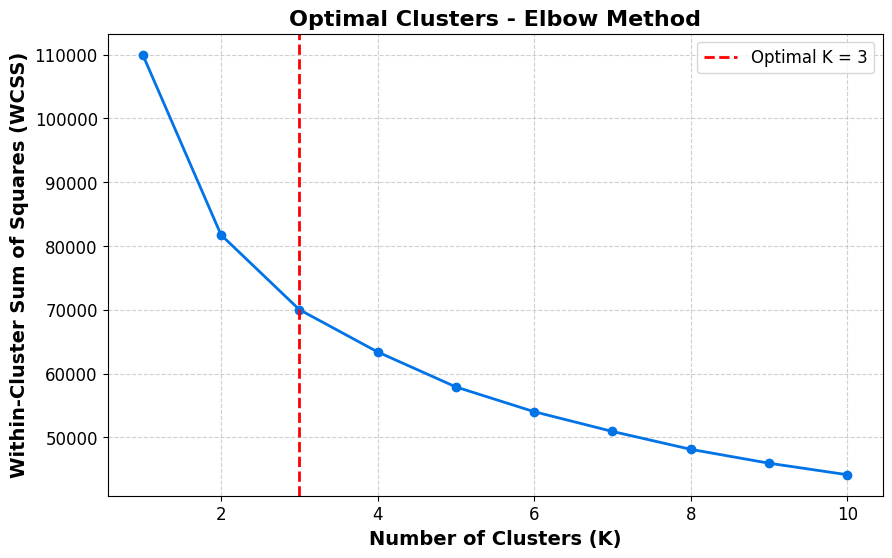

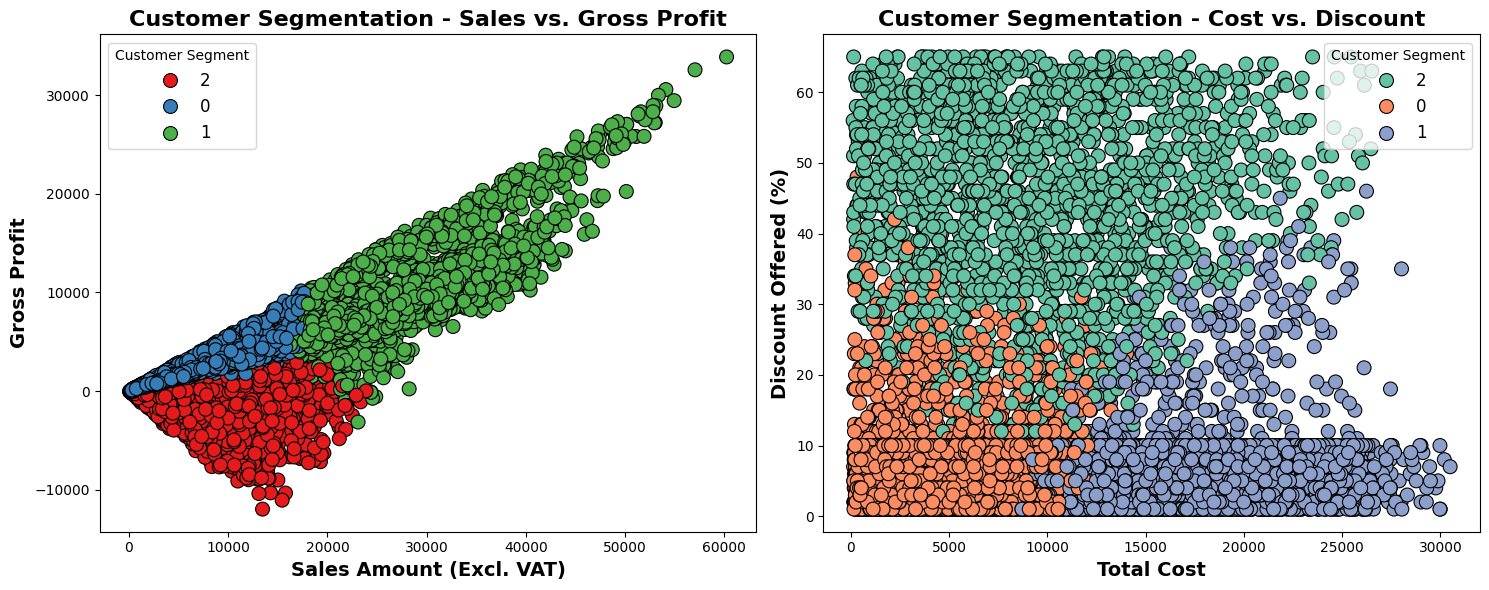

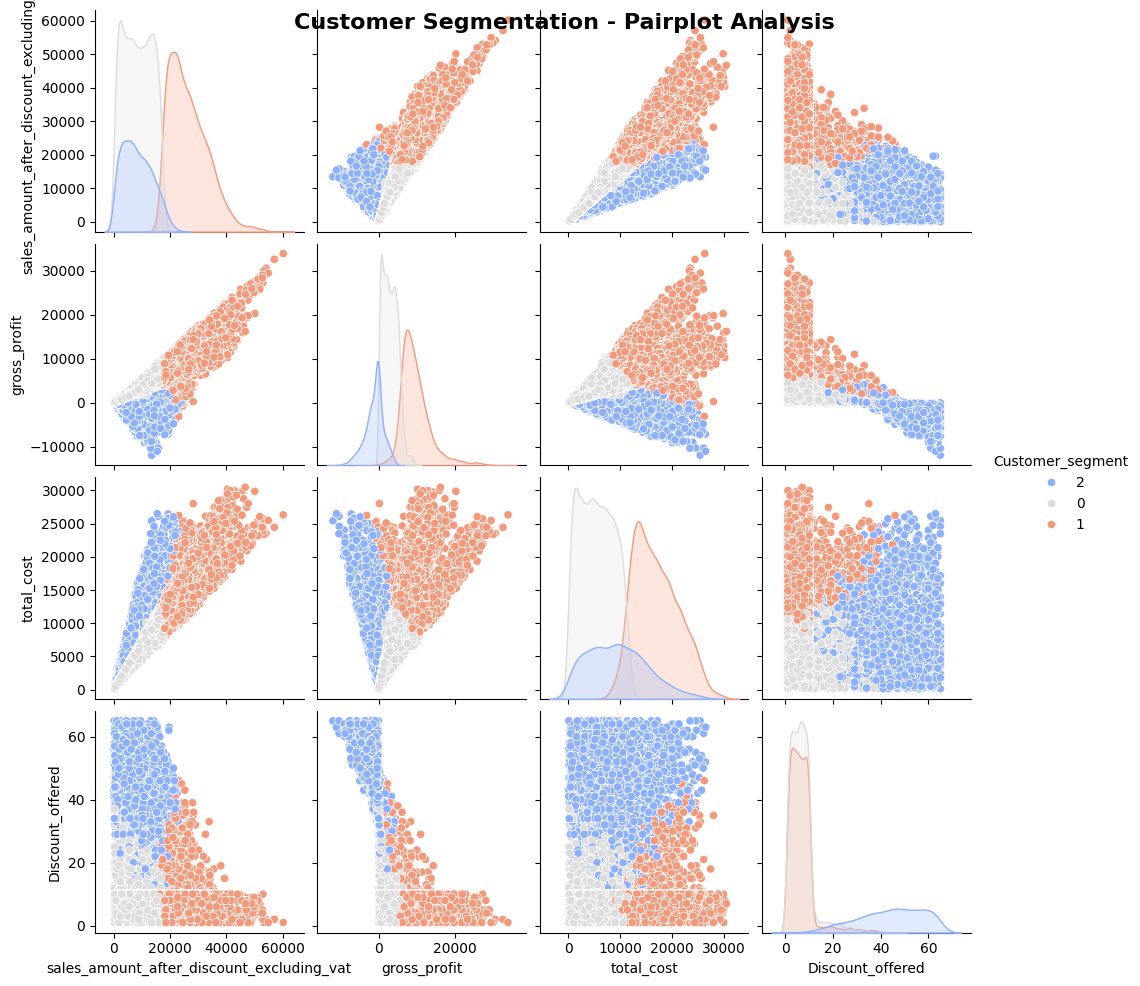

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# Selecting features for clustering
cluster_features = ['Customer_care_calls', 'Customer_rating', 'Prior_purchases',
                    'Discount_offered', 'Weight_in_gms', 'price', 'quantity',
                    'total_cost', 'sales_amount_after_discount_excluding_vat', 'gross_profit']

# Standardizing the data for K-Means
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[cluster_features])

# Finding the optimal number of clusters using the Elbow Method
wcss = []
K_range = range(1, 11)  # Checking from 1 to 10 clusters
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# 🔹 Plot the Elbow Method (Enhanced for Presentation)
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', linestyle='-', color='#0073e6', linewidth=2)
plt.xlabel('Number of Clusters (K)', fontsize=14, fontweight='bold')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=14, fontweight='bold')
plt.title('Optimal Clusters - Elbow Method', fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Highlighting the optimal K visually
optimal_k = 3  # Based on the expected best K
plt.axvline(optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal K = {optimal_k}')
plt.legend(fontsize=12)
plt.show()

# 🔹 Running K-Means with the optimal K
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Customer_segment'] = kmeans.fit_predict(df_scaled)
df['Customer_segment'] = df['Customer_segment'].astype(str)  # Convert to string for seaborn coloring

# 🔹 Visualizing Customer Segments Professionally
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Scatter Plot (Sales vs. Gross Profit)
sns.scatterplot(x=df['sales_amount_after_discount_excluding_vat'],
                y=df['gross_profit'],
                hue=df['Customer_segment'],
                palette='Set1',
                s=100,
                edgecolor='black',
                ax=ax[0])
ax[0].set_xlabel('Sales Amount (Excl. VAT)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Gross Profit', fontsize=14, fontweight='bold')
ax[0].set_title('Customer Segmentation - Sales vs. Gross Profit', fontsize=16, fontweight='bold')
ax[0].legend(title="Customer Segment", fontsize=12)

# Scatter Plot (Total Cost vs. Discount Offered)
sns.scatterplot(x=df['total_cost'],
                y=df['Discount_offered'],
                hue=df['Customer_segment'],
                palette='Set2',
                s=100,
                edgecolor='black',
                ax=ax[1])
ax[1].set_xlabel('Total Cost', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Discount Offered (%)', fontsize=14, fontweight='bold')
ax[1].set_title('Customer Segmentation - Cost vs. Discount', fontsize=16, fontweight='bold')
ax[1].legend(title="Customer Segment", fontsize=12)

plt.tight_layout()
plt.show()

# 🔹 Pairplot for deeper visualization
sns.pairplot(df, hue="Customer_segment", palette='coolwarm',
             vars=['sales_amount_after_discount_excluding_vat', 'gross_profit', 'total_cost', 'Discount_offered'])
plt.suptitle('Customer Segmentation - Pairplot Analysis', fontsize=16, fontweight='bold')
plt.show()

**Key Insights from the Clustering Results**

🔴 **Cluster 2 (Red - Low Gross Profit, High Discount)**
- Customers in this group receive **high discounts (30% - 50%)**.
- **Low gross profit** as high discounts significantly reduce margins.
- **High total cost** → They buy in bulk or purchase expensive products.
- **Strategy:** Reduce discounts or shift these customers into a more sustainable pricing model.

🔵 **Cluster 0 (Blue - High Sales & Gross Profit)**
- These customers **spend the most** and **generate the highest profit**.
- **Less price-sensitive** and willing to pay higher prices.
- **Strategy:** Keep them engaged through **loyalty programs** instead of offering heavy discounts.

🟢 **Cluster 1 (Green - Mid-Tier Customers)**
- Customers in this segment **have moderate sales and profit**.
- **Respond well to discounts** but do not always buy in large quantities.
- **Strategy:** Use **personalized pricing** and **upsell strategies** to increase their spending.


\
\
**Optimized Strategies to Maximize Gross Profit:**


**✅ 1. Optimize Discounts & Promotions**

**Reduce Discounts for Cluster 2 (Red - Low Profit)**
- Customers in this group receive **very high discounts (above 30%)** but generate **low profit**.
- Modify "Clearance Promo" (45% off) to a more sustainable **20%-25% discount**.
- Instead of high discounts, offer **free shipping** or **bundle deals** to maintain perceived value.

**Increase Discounts for High-Spending Customers (Cluster 0)**
- Since this group drives **high sales and profit**, encourage them to **buy more frequently** with **tiered rewards**.
- Offer a **"Thank You Customer Coupon"** (5% discount) on future purchases instead of upfront discounts to increase retention.

**✅ 2. Adjust Pricing Model (Reduce Cost, Improve Margins)**

**Optimize Profit Margins for Different Customer Segments**
- Adjust pricing dynamically based on customer segments:
  - **Cluster 0 (High Profit):** Maintain a **35%** profit margin.
  - **Cluster 1 (Mid Profit):** Increase margin to **40%** for better profitability.
  - **Cluster 2 (Low Profit):** Reduce margin to **25%** to make products more attractive.

**Increase Product Importance Multiplier for High-Profit Items**
- **Adjust multipliers based on sales performance:**
  - Increase **low-importance** product margins slightly to balance costs.
  - Keep **medium-importance** product margins stable.
  - **Increase high-importance** product margins to encourage higher spending on premium items.

**✅ 3. Customer-Specific Pricing Strategy**

**Introduce Personalized Pricing**
- **Cluster 0 →** No discounts, but offer **exclusive early access** to new products.
- **Cluster 1 →** Moderate discounts (**5% - 15%**) to encourage repeat purchases.
- **Cluster 2 →** Small discounts but **higher perceived value** through **loyalty perks, free shipping, or bundle deals**.

**Use Predictive Modeling to Identify High-Value Customers Early**
- **Develop a classification model** based on customer purchase history to **predict high-profit customers**.
- **Proactively offer personalized incentives** to prevent profitable customers from shifting to **low-margin discount groups**.

**📌 Conclusion:**
✅ Reduce discounts for **low-profit customers** (Cluster 2).  
✅ Keep **high-profit customers engaged** with **personalized offers** (Cluster 0).  
✅ **Dynamically adjust pricing** based on customer segments.  
✅ **Increase margins for high-value products** to improve overall profitability.  


In [ ]:
df

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,promo_type,warehouse_multiplier,shipment_multiplier,importance_multiplier,total_multiplier,price,quantity,total_cost,sales_amount_before_discount,sales_amount_after_discount_excluding_vat,sales_amount_after_discount_including_vat,discount_amount,gross_profit,Warehouse_block_encoded,Mode_of_Shipment_encoded,Product_importance_encoded,Gender_encoded,promo_type_encoded,Customer_segment
0,1,D,Flight,4,2,177,3,low,F,44,1233,1,10thAnni_Promo,0.03,0.15,0.025,1.58995,281.42115,79,13983,22232.27085,12450.071676,13321.576693,9782.199174,-1532.928324,4,1,2,1,1,2
1,2,F,Flight,4,5,216,2,low,M,59,3088,1,Clearance_Promo,0.11,0.15,0.025,1.94820,420.81120,68,14688,28615.16160,11732.216256,12553.471394,16882.945344,-2955.783744,5,1,2,2,2,2
2,3,A,Flight,2,2,183,4,low,M,48,3374,1,Clearance_Promo,0.05,0.15,0.025,1.93110,353.39130,4,732,1413.56520,735.053904,786.507677,678.511296,3.053904,1,1,2,2,2,2
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1,Flash_Sales_Coupon,0.07,0.15,0.050,1.64655,289.79280,2,352,579.58560,521.627040,558.140933,57.958560,169.627040,2,1,3,2,3,0
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1,Clearance_Promo,0.09,0.15,0.050,1.86260,342.71840,75,13800,25703.88000,13880.095200,14851.701864,11823.784800,80.095200,3,1,3,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1,Thank_you_Customer_Coupon,0.05,0.03,0.050,1.49614,377.02728,36,9072,13572.98208,13437.252259,14377.859917,135.729821,4365.252259,1,3,3,1,4,0
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0,Flash_Sales_Coupon,0.07,0.03,0.050,1.50741,349.71912,69,16008,24130.61928,22682.782123,24270.576872,1447.837157,6674.782123,2,3,3,1,3,1
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0,Thank_you_Customer_Coupon,0.09,0.03,0.025,1.49965,362.91530,26,6292,9435.79780,9058.365888,9692.451500,377.431912,2766.365888,3,3,2,1,4,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0,Thank_you_Customer_Coupon,0.11,0.03,0.050,1.54630,344.82490,26,5798,8965.44740,8786.138452,9401.168144,179.308948,2988.138452,5,3,3,2,4,0


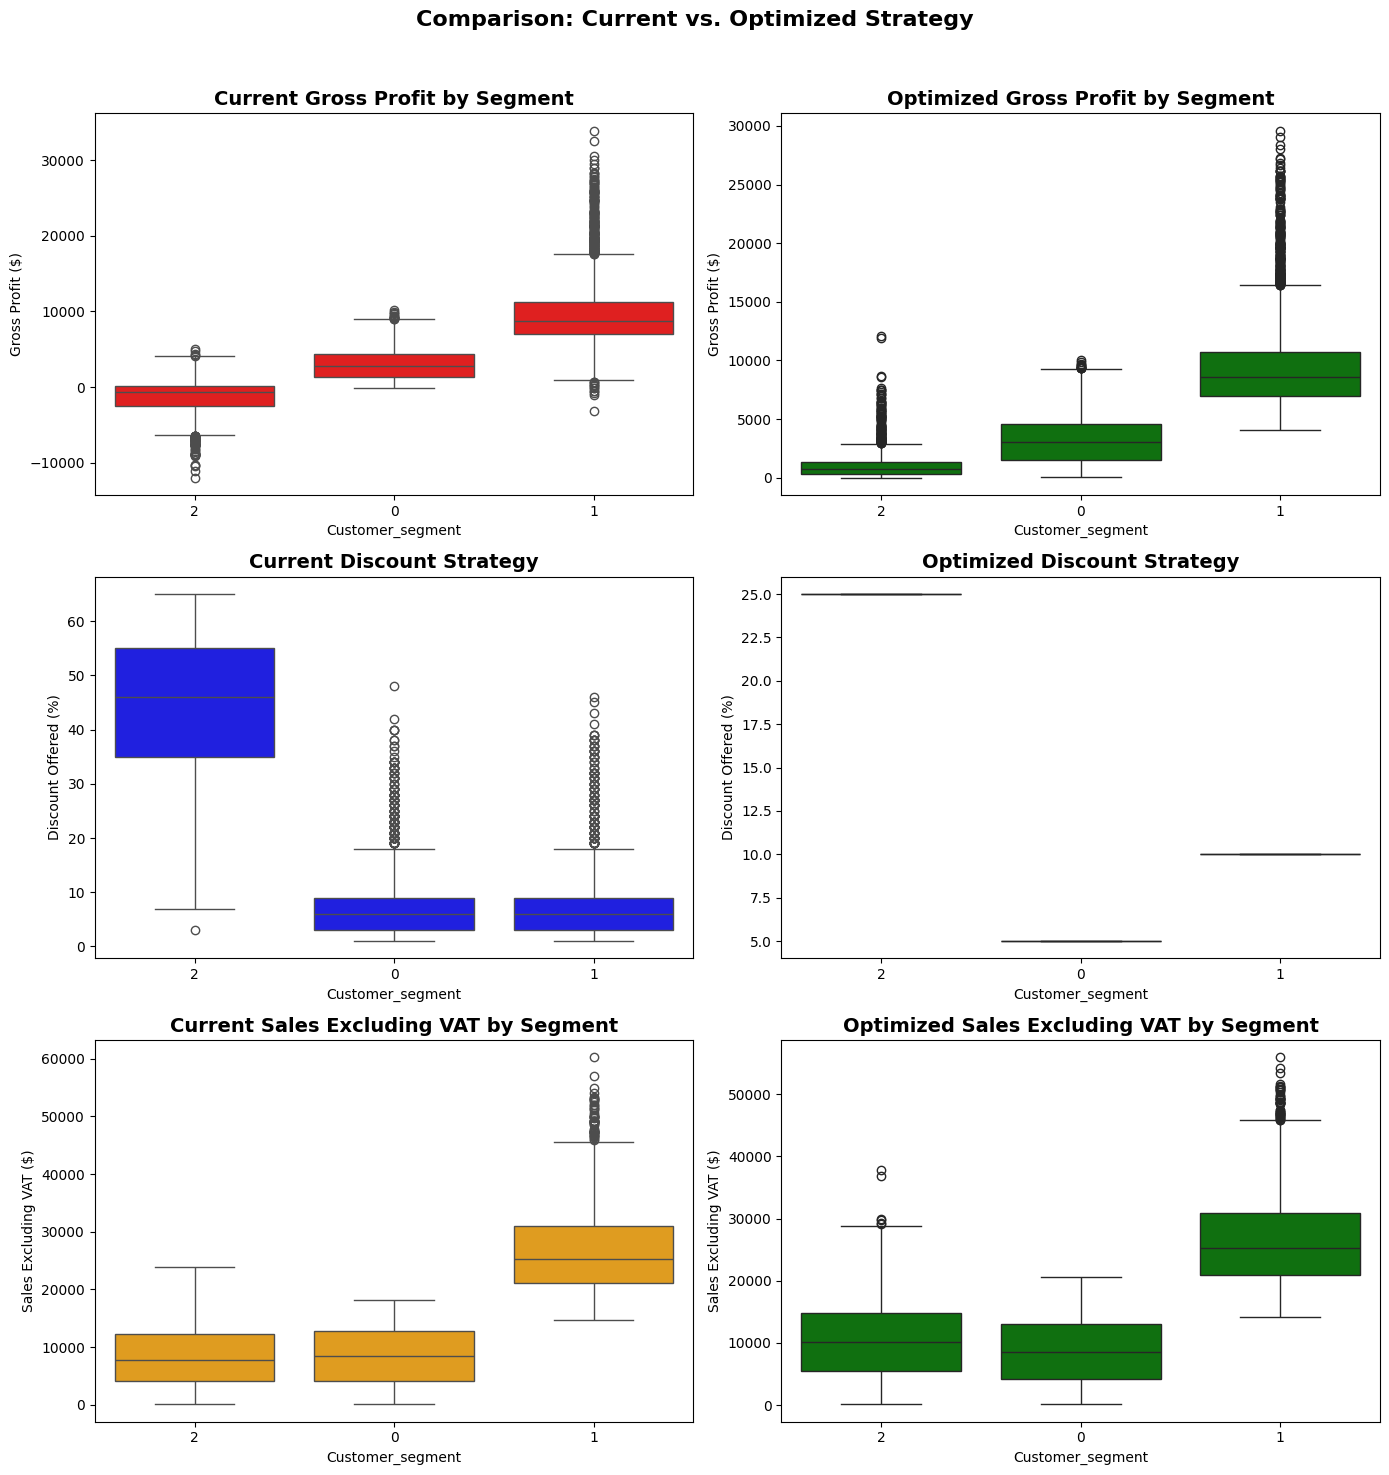

In [ ]:
# Creating new strategy columns based on optimization recommendations

# New dynamic profit margins based on customer segments
profit_margin_map = {'0': 0.35, '1': 0.40, '2': 0.25}  # Adjusted margins per segment
df['new_profit_margin'] = df['Customer_segment'].map(profit_margin_map)

# Adjusted total multiplier using new profit margins
df['new_total_multiplier'] = (df['warehouse_multiplier'] +
                             (df['shipment_multiplier'] * df['Weight_in_gms'] / 1000) +
                             df['importance_multiplier'] + df['new_profit_margin'] + 1)

# Adjusted price based on new multiplier
df['new_price'] = df['Cost_of_the_Product'] * df['new_total_multiplier']

# Adjusted discount strategy based on customer segment
discount_map = {'0': 5, '1': 10, '2': 25}  # Reduced discounts for Cluster 2
df['new_Discount_offered'] = df['Customer_segment'].map(discount_map)

# Adjusted sales calculations with new strategy
df['new_sales_amount_before_discount'] = df['quantity'] * df['new_price']
df['new_sales_amount_after_discount_excluding_vat'] = df['quantity'] * (1 - df['new_Discount_offered'] / 100) * df['new_price']
df['new_sales_amount_after_discount_including_vat'] = df['new_sales_amount_after_discount_excluding_vat'] * 1.07
df['new_discount_amount'] = df['new_sales_amount_before_discount'] - df['new_sales_amount_after_discount_excluding_vat']
df['new_gross_profit'] = df['new_sales_amount_after_discount_excluding_vat'] - df['total_cost']


# Handling missing values correctly
df['new_gross_profit'] = df['new_gross_profit'].fillna(0)
df['new_Discount_offered'] = df['new_Discount_offered'].fillna(df['Discount_offered'].median())

# Ensuring all values are numeric
df['new_gross_profit'] = pd.to_numeric(df['new_gross_profit'], errors='coerce')
df['new_Discount_offered'] = pd.to_numeric(df['new_Discount_offered'], errors='coerce')

# Creating visualization with additional row for sales amount
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.suptitle("Comparison: Current vs. Optimized Strategy", fontsize=16, fontweight='bold')

# Gross Profit Comparison
sns.boxplot(data=df, x="Customer_segment", y="gross_profit", ax=axes[0, 0], color='red')
sns.boxplot(data=df, x="Customer_segment", y="new_gross_profit", ax=axes[0, 1], color='green')

axes[0, 0].set_title("Current Gross Profit by Segment", fontsize=14, fontweight='bold')
axes[0, 1].set_title("Optimized Gross Profit by Segment", fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel("Gross Profit ($)")
axes[0, 1].set_ylabel("Gross Profit ($)")

# Discount Comparison
sns.boxplot(data=df, x="Customer_segment", y="Discount_offered", ax=axes[1, 0], color='blue')
sns.boxplot(data=df, x="Customer_segment", y="new_Discount_offered", ax=axes[1, 1], color='purple')

axes[1, 0].set_title("Current Discount Strategy", fontsize=14, fontweight='bold')
axes[1, 1].set_title("Optimized Discount Strategy", fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel("Discount Offered (%)")
axes[1, 1].set_ylabel("Discount Offered (%)")

# Sales Excluding VAT Comparison (Bar Chart)
sns.boxplot(data=df, x="Customer_segment", y="sales_amount_after_discount_excluding_vat", ax=axes[2, 0], color='orange')
sns.boxplot(data=df, x="Customer_segment", y="new_sales_amount_after_discount_excluding_vat", ax=axes[2, 1], color='green')

axes[2, 0].set_title("Current Sales Excluding VAT by Segment", fontsize=14, fontweight='bold')
axes[2, 1].set_title("Optimized Sales Excluding VAT by Segment", fontsize=14, fontweight='bold')
axes[2, 0].set_ylabel("Sales Excluding VAT ($)")
axes[2, 1].set_ylabel("Sales Excluding VAT ($)")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

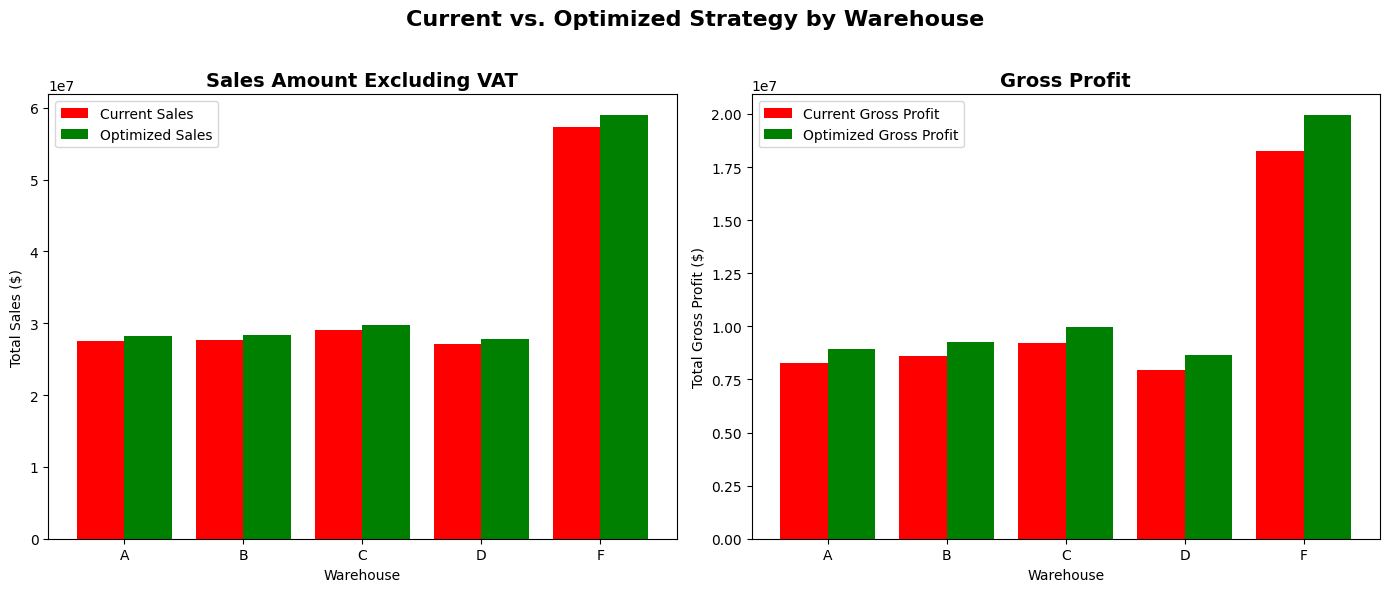

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Grouping data by Warehouse and summing sales and gross profit
warehouse_summary = df.groupby("Warehouse_block")[
    ["sales_amount_after_discount_excluding_vat", "new_sales_amount_after_discount_excluding_vat",
     "gross_profit", "new_gross_profit"]
].sum()

# Creating a grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Current vs. Optimized Strategy by Warehouse", fontsize=16, fontweight='bold')

# Sales Amount Excluding VAT Comparison
x = np.arange(len(warehouse_summary.index))
width = 0.4

axes[0].bar(x - width/2, warehouse_summary["sales_amount_after_discount_excluding_vat"],
            width=width, label="Current Sales", color="red")
axes[0].bar(x + width/2, warehouse_summary["new_sales_amount_after_discount_excluding_vat"],
            width=width, label="Optimized Sales", color="green")

axes[0].set_title("Sales Amount Excluding VAT", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Warehouse")
axes[0].set_ylabel("Total Sales ($)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(warehouse_summary.index)
axes[0].legend()

# Gross Profit Comparison
axes[1].bar(x - width/2, warehouse_summary["gross_profit"],
            width=width, label="Current Gross Profit", color="red")
axes[1].bar(x + width/2, warehouse_summary["new_gross_profit"],
            width=width, label="Optimized Gross Profit", color="green")

axes[1].set_title("Gross Profit", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Warehouse")
axes[1].set_ylabel("Total Gross Profit ($)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(warehouse_summary.index)
axes[1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### **Classification : Customer Rating**

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Conv1D, Flatten
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define features and target
features = ['Customer_care_calls', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'price', 'quantity',
            'total_cost', 'gross_profit', 'Warehouse_block_encoded', 'Mode_of_Shipment_encoded',
            'Product_importance_encoded', 'Gender_encoded', 'promo_type_encoded']
target = 'Customer_rating'

df_CLS = df.copy()
# Transform target variable into binary classification (Satisfied vs. Unsatisfied)
df_CLS['Customer_satisfaction'] = df_CLS[target].apply(lambda x: '1 : Satisfied' if x >= 3 else '0 : Unsatisfied')

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_CLS[features])

# Encode target variable with fixed mapping (Satisfied -> 1, Unsatisfied -> 0)
label_encoder = LabelEncoder()
label_encoder.fit(['0 : Unsatisfied', '1 : Satisfied'])  # Ensure fixed order
y_encoded = label_encoder.transform(df_CLS['Customer_satisfaction'])

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

# Reshape data for RNN/LSTM (samples, timesteps, features)
X_train_rnn, X_test_rnn = X_train.reshape(-1, 1, X_train.shape[1]), X_test.reshape(-1, 1, X_test.shape[1])

# Store predictions and metrics
model_results = {}
confusion_matrices = {}

# Function to train & evaluate models
def train_and_evaluate(model, X_train, y_train, X_test, y_test, name):
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

    y_pred = (model.predict(X_test) > 0.5).astype("int32").flatten()
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=1)

    model_results[name] = {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-Score": f1}
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

    return accuracy, precision, recall, f1

# 🚀 ANN Model
ann_model_CLS = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
train_and_evaluate(ann_model, X_train, y_train, X_test, y_test, "ANN_CLS")

# 🚀 RNN Model
rnn_model_CLS = Sequential([
    SimpleRNN(50, activation='relu', return_sequences=True, input_shape=(1, X_train.shape[1])),
    SimpleRNN(50, activation='relu'),
    Dense(1, activation='sigmoid')
])
train_and_evaluate(rnn_model, X_train_rnn, y_train, X_test_rnn, y_test, "RNN_CLS")

# 🚀 CNN Model (Fixed: Ensure Sequence Length >= 2)
sequence_length = 2

# Function to create sequences for CNN model
def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i: i + seq_length])
        ys.append(y[i + seq_length])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, sequence_length)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, sequence_length)

cnn_mode_CLSl = Sequential([
    Conv1D(64, kernel_size=2, activation='relu', input_shape=(sequence_length, X_train.shape[1])),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
train_and_evaluate(cnn_model, X_train_seq, y_train_seq, X_test_seq, y_test_seq, "CNN_CLS")

# 🚀 LSTM Model
lstm_model_CLS = Sequential([
    LSTM(50, activation='relu', return_sequences=True, input_shape=(1, X_train.shape[1])),
    LSTM(50, activation='relu'),
    Dense(1, activation='sigmoid')
])
train_and_evaluate(lstm_model, X_train_rnn, y_train, X_test_rnn, y_test, "LSTM_CLS")


Epoch 1/20


/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6006 - loss: 6.3670
Epoch 2/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5938 - loss: 6.4765
Epoch 3/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5968 - loss: 6.4282
Epoch 4/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5961 - loss: 6.4395
Epoch 5/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5992 - loss: 6.3891
Epoch 6/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5950 - loss: 6.4560
Epoch 7/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6007 - loss: 6.3650
Epoch 8/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5980 - loss: 6.4086
Epoch 9/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5922 - loss: 6.5018
Epoch 10/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5963 - loss: 6.4356
Epoch 11/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5943 - loss: 6.4671
Epoch 12/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy

/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6020 - loss: 6.3456
Epoch 2/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6030 - loss: 6.3293
Epoch 3/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5980 - loss: 6.4081
Epoch 4/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5916 - loss: 6.5104
Epoch 5/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5921 - loss: 6.5027
Epoch 6/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6057 - loss: 6.2862
Epoch 7/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6106 - loss: 6.2076
Epoch 8/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5980 - loss: 6.4089
Epoch 9/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5959 - loss: 6.4416
Epoch 10/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5964 - loss: 6.4338
Epoch 11/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6005 - loss: 6.3684
Epoch 12/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy

/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5994 - loss: 6.3862
Epoch 2/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6005 - loss: 6.3693
Epoch 3/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5944 - loss: 6.4655
Epoch 4/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5979 - loss: 6.4110
Epoch 5/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5926 - loss: 6.4950
Epoch 6/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5910 - loss: 6.5197
Epoch 7/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5903 - loss: 6.5319
Epoch 8/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6044 - loss: 6.3068
Epoch 9/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5956 - loss: 6.4465
Epoch 10/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6061 - loss: 6.2792
Epoch 11/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6001 - loss: 6.3752
Epoch 12/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy

/Users/saranthaworn/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


550/550 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5994 - loss: 6.3862
Epoch 2/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6054 - loss: 6.2906
Epoch 3/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6041 - loss: 6.3122
Epoch 4/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5969 - loss: 6.4266
Epoch 5/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5977 - loss: 6.4143
Epoch 6/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6046 - loss: 6.3042
Epoch 7/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6078 - loss: 6.2533
Epoch 8/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5996 - loss: 6.3834
Epoch 9/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6048 - loss: 6.3004
Epoch 10/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5995 - loss: 6.3848
Epoch 11/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6021 - loss: 6.3438
Epoch 12/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy

(0.6, 0.6, 1.0, 0.7499999999999999)


📊 Model Classification Performance:


,Accuracy,Precision,Recall,F1-Score
ANN_CLS,0.600000,0.600000,1.0,0.750000
RNN_CLS,0.600000,0.600000,1.0,0.750000
CNN_CLS,0.599636,0.599636,1.0,0.749716
LSTM_CLS,0.600000,0.600000,1.0,0.750000


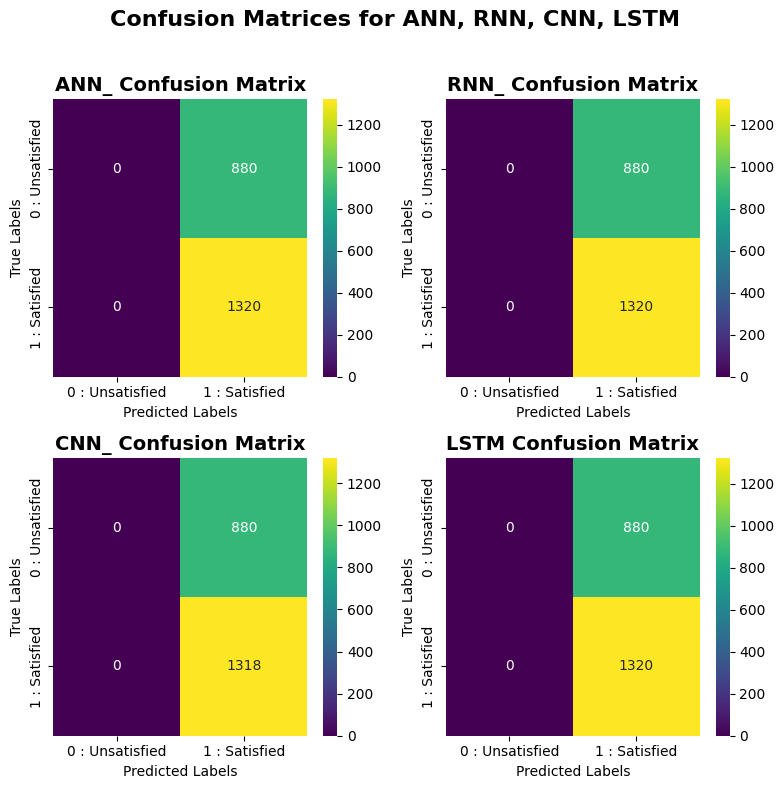

In [ ]:
# =============================
# ✅ Display Results
# =============================
results_df = pd.DataFrame(model_results).T
print("\n📊 Model Classification Performance:")
display(results_df)

# =============================
# 📊 Visualizing Confusion Matrices
# =============================

# 📊 Visualizing Confusion Matrices with Proper Axis Mapping (0 = Unsatisfied, 1 = Satisfied)
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
fig.suptitle("Confusion Matrices for ANN, RNN, CNN, LSTM", fontsize=16, fontweight='bold')

models = ["ANN_CLS", "RNN_CLS", "CNN_CLS", "LSTM_CLS"]
class_labels = ["0 : Unsatisfied", "1 : Satisfied"]

for i, model in enumerate(models):
    ax = axes[i//2, i%2]
    sns.heatmap(confusion_matrices[model], annot=True, fmt="d", cmap="viridis", ax=ax, xticklabels=class_labels, yticklabels=class_labels)
    ax.set_title(f"{model[:4]} Confusion Matrix", fontsize=14, fontweight='bold')
    ax.set_xlabel("Predicted Labels")
    ax.set_ylabel("True Labels")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
